In [6]:
%matplotlib inline
import matplotlib as mpl
import matplotlib.pyplot as plt
from matplotlib import gridspec

import numpy as np
from scipy.stats import gaussian_kde

## set default matplotlib font and font size
typeface='helvetica'
mpl.rcParams['font.weight']=300
mpl.rcParams['axes.labelweight']=300
mpl.rcParams['font.family']=typeface
mpl.rcParams['font.size']=22

import os,random
from itertools import permutations

import sys
#sys.path.append('/Users/nmueller/Documents/github/CoInfection-Material/Applications/NetworkViz/')
import baltic_bacter as bt
print('loaded')

import pandas as pd

loaded


combined/HPAI_HLHxNx.independent.tree
[2023.3260273972603, 2024.7704918032787, 2024.7814207650274, 2024.8524590163934, 2023.8082191780823, 2024.8715846994535, 2022.868493150685, 2023.0246575342467, 2023.849315068493, 2024.9972677595629, 2024.9016393442623, 2025.0767123287671, 2025.0630136986301, 2025.1068493150685, 2024.9972677595629, 2025.0712328767124, 2025.0054794520547, 2025.0383561643835, 2024.8387978142077, 2025.0931506849315, 2025.0767123287671, 2025.0383561643835, 2024.8224043715848, 2024.948087431694, 2025.0739726027398, 2025.027397260274, 2024.9972677595629, 2025.1287671232876, 2024.9590163934427, 2024.9617486338798, 2024.9344262295083, 2024.9590163934427, 2024.9289617486338, 2024.9098360655737, 2025.041095890411, 2025.0657534246575, 2024.9234972677596, 2025.021917808219, 2024.8060109289618, 2025.0465753424658, 2025.0712328767124, 2025.054794520548, 2024.9398907103825, 2025.0986301369862, 2024.879781420765, 2022.8219178082193, 2023.2630136986302, 2023.041095890411, 2023.17534

/var/folders/s8/16mqst794hgfqn_ky459vws40000gq/T/ipykernel_31725/333296092.py:329: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


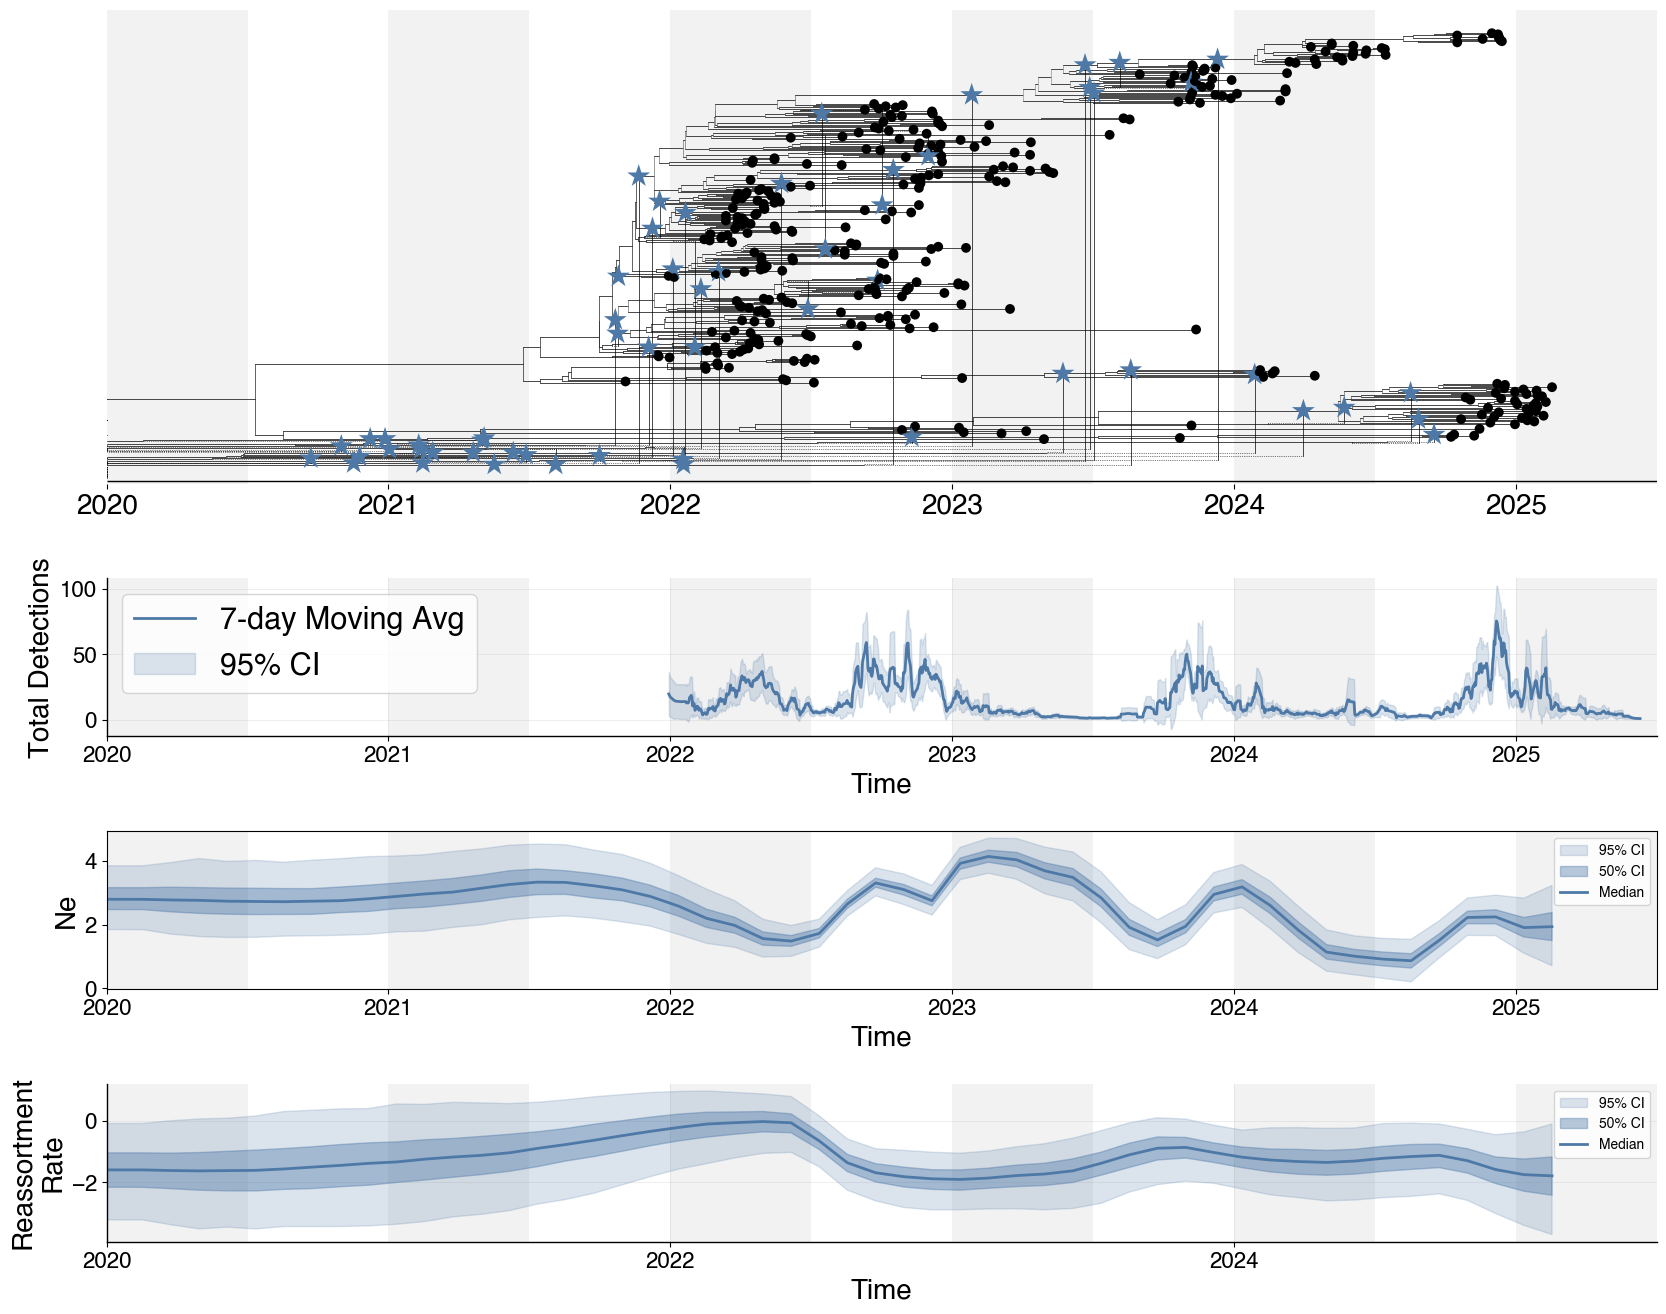

H5N1_independent_combined.pdf
combined/HPAI_HLHxNx.dependent.tree
[2022.1260273972603, 2022.1698630136987, 2022.4383561643835, 2022.5123287671233, 2022.4849315068493, 2022.4767123287672, 2022.1671232876713, 2022.1671232876713, 2022.2082191780821, 2022.123287671233, 2022.3534246575343, 2022.2986301369863, 2022.2547945205479, 2022.9342465753425, 2022.7808219178082, 2022.6794520547944, 2022.641095890411, 2022.849315068493, 2023.8657534246574, 2022.868493150685, 2022.3397260273973, 2022.7424657534248, 2022.835616438356, 2022.772602739726, 2022.772602739726, 2022.227397260274, 2022.1479452054793, 2022.482191780822, 2022.2849315068493, 2022.4876712328767, 2022.4986301369863, 2022.2986301369863, 2022.1972602739727, 2022.6054794520549, 2023.2054794520548, 2022.2520547945205, 2022.2794520547945, 2022.3945205479451, 2022.731506849315, 2022.668493150685, 2022.7287671232878, 2022.704109589041, 2022.972602739726, 2022.7369863013698, 2022.8383561643836, 2022.7671232876712, 2022.7424657534248, 2022.7

/var/folders/s8/16mqst794hgfqn_ky459vws40000gq/T/ipykernel_31725/333296092.py:329: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


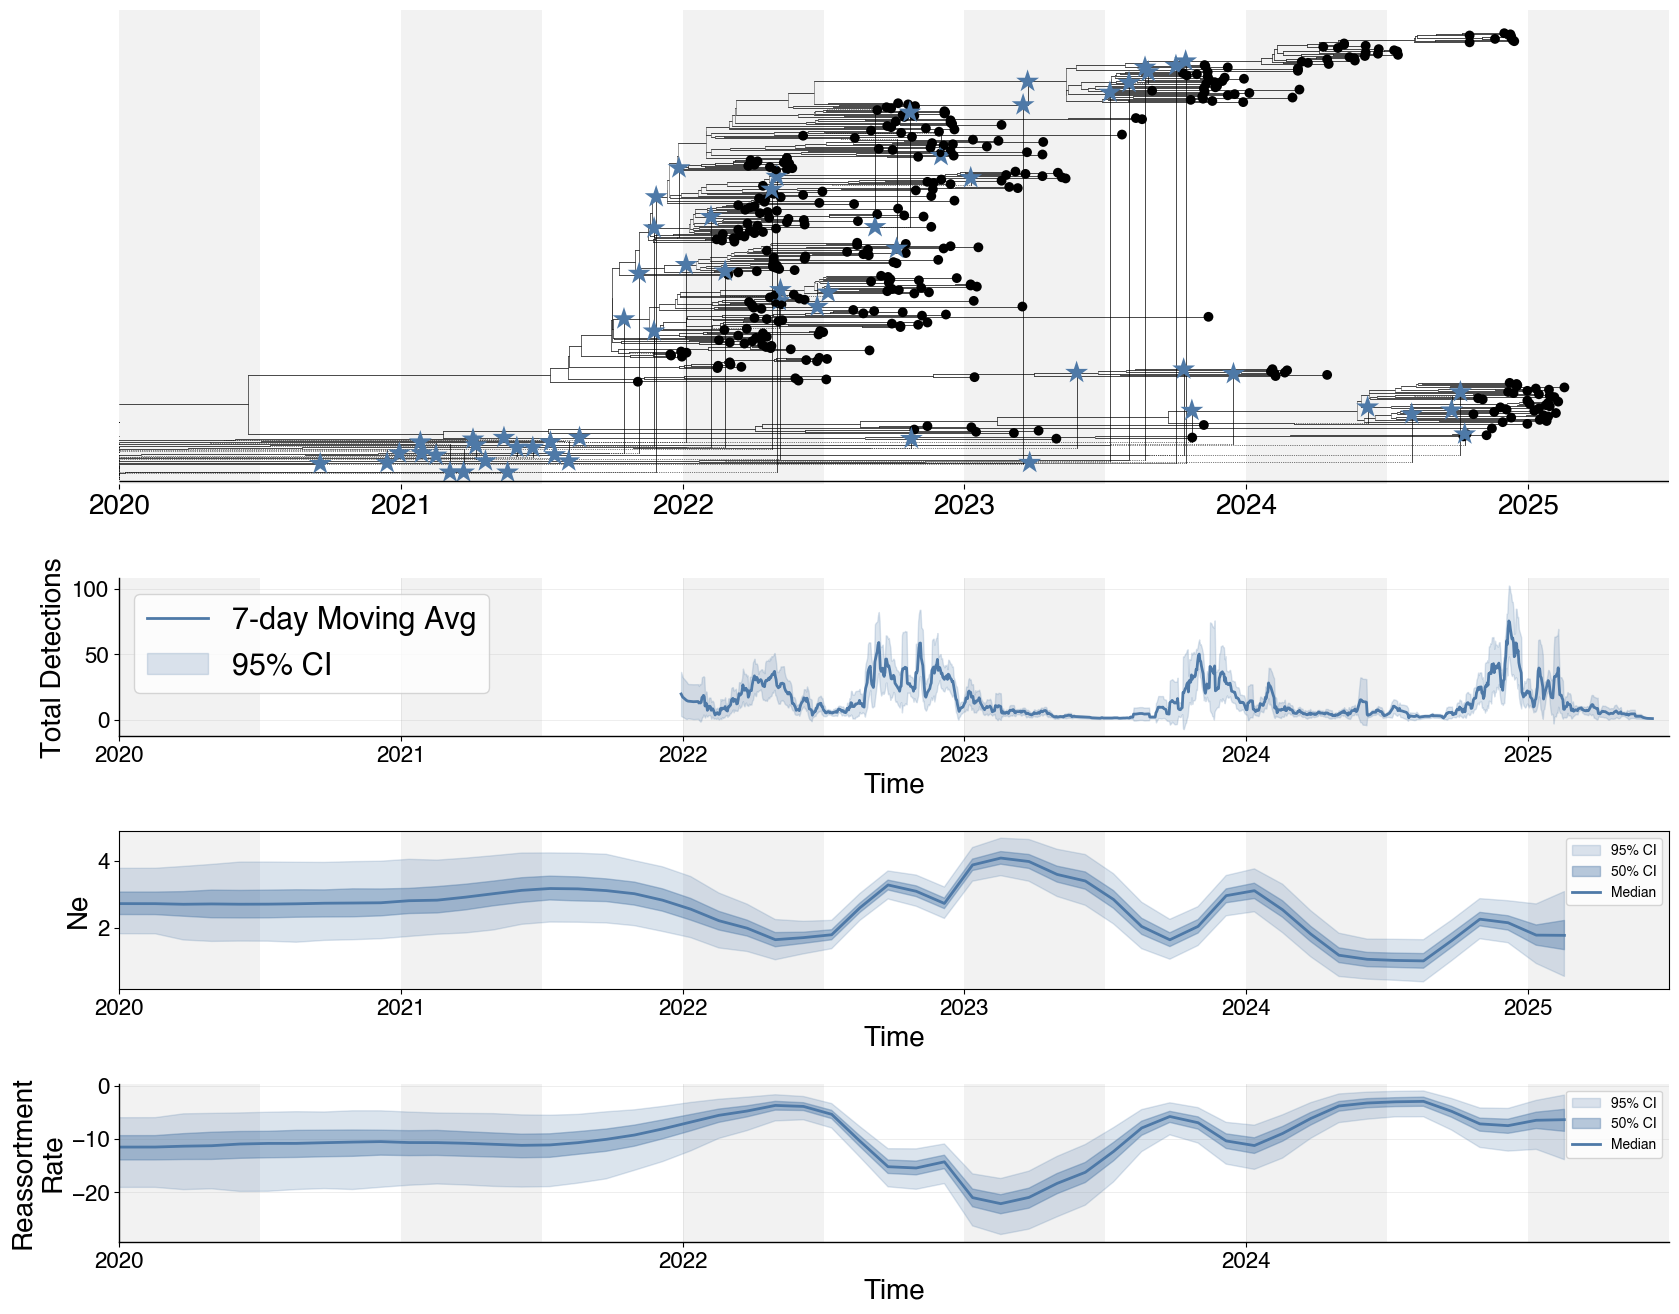

H5N1_dependent_combined.pdf


In [19]:
colours = {'red', 'green'}

segments = ['HA', 'NA', 'MP', 'NS', 'NP', 'PB1', 'PB2', 'PA']

new_order = [0, 1, 2, 4, 7, 5, 6, 3]

colour_cycle = ['#969696', '#737373', '#525252', '#252525']
# colour_cycle = ["#b3cde3", "#8cadd1", "#6497b1", "#005b96", "#03396c"]

path = 'combined/'

linewidth = 0.5

colors_event = {
    "true+false+false": '#4E79A7',
    "false+true+false": '#F28E2B',
    "false+false+true": '#E15759',
    "true+true+false":  '#76B7B2',
    "true+false+true":  '#59A14F',
    "false+true+true":  '#EDC948',
    "true+true+true":   '#B07AA1',
}

for approach in ['independent', 'dependent']:
    fig = plt.figure(figsize=(20, 16), facecolor='w')  # 4 panels
    gs = fig.add_gridspec(4, 1, height_ratios=[6, 2, 2, 2], hspace=0.4)
    
    ax  = fig.add_subplot(gs[0, 0], facecolor='w')  # phylo tree
    ax_detect = fig.add_subplot(gs[1, 0], facecolor='w')  # detections panel
    ax_ne = fig.add_subplot(gs[2, 0], facecolor='w')  # Ne plot
    ax_rates = fig.add_subplot(gs[3, 0], facecolor='w')  # reassortment rate

    c1 = 0
    c2 = 0    
    # filename of type H5N1_wgs_proportional.constant.combined.0_7.reassortment
    file = 'HPAI_HLHxNx.' + approach + '.tree'
    tree_path = os.path.join(path, file)
    print(tree_path)
    ll = bt.loadNexus(tree_path, date_fmt='%Y-%m-%d', verbose=False)  # load tree
    seg_count = 0
    ll.drawTree()
    c2 += 1
    if c2 == 2:
        c1 += 1
        c2 = 0

    ax.set_facecolor('w')
    [ax.spines[loc].set_visible(False) for loc in ax.spines if loc != 'bottom']  # remove axis spines

    fromval = float(int(ll.root.absoluteTime + ll.treeHeight)) - 5
    toval = float(int(ll.root.absoluteTime + ll.treeHeight)) + 0.5
    
    timewidth=0.5
    # for i in np.arange(ll.root.absoluteTime - 1, ll.root.absoluteTime + ll.treeHeight + 1, 1.0):
    #     ax.axvline(i, ls='-', color='lightgrey', lw=1, alpha=0.2)  # Add timeline
    for i in np.arange(fromval, toval, 2 * timewidth):
        ax.axvspan(i, i + timewidth, facecolor='#F2F2F2', edgecolor='none', alpha=1, zorder=0)  # Add timeline

    for k in ll.Objects:
        k.traits['re'] = 0

    curr_traits_number = 0

    # Collect reassortment events for rate calculation
    reassortment_events = []

    for k in sorted(ll.Objects, key=lambda w: w.height):  # iterate through branches, starting with oldest ones
        if hasattr(k, 'contribution'):  # if branch is the result of reassortment
            # pick a number at random between 0 and len(colour_cycle) that is not == w.traits['re']
            random_number = random.randint(0, len(colour_cycle) - 1)
            while random_number == k.traits['re']:
                random_number = random.randint(0, len(colour_cycle) - 1)

            subtree = ll.traverse_tree(k.children[-1], include_condition=lambda w: True)  # traverse the subtree
            for w in subtree:  # for every branch in subtree
                w.traits['re'] = random_number

    for k in ll.Objects:  # iterate over branches
        x = k.absoluteTime
        xp = k.parent.absoluteTime
        if xp != None:
            xp = max(xp, fromval+0.000001)
        y = k.y
        col = colour_cycle[k.traits['re'] % len(colour_cycle)]  # get colour out of colour cycle
        col = 'black'
        if isinstance(k, bt.reticulation) == False:  # if a regular branch
            ax.plot([x, xp], [y, y], color=col, lw=linewidth, solid_capstyle='round')
        else:
            ax.plot([x, xp], [y, y], color=col, lw=linewidth, ls=':', solid_capstyle='round')  # reassortment branches are black

        if k.branchType == 'node':  # if node - plot vertical bar
            left, right = k.children[-1].y, k.children[0].y

            col1 = colour_cycle[k.children[-1].traits['re'] % len(colour_cycle)]  # get colour out of colour cycle
            col2 = colour_cycle[k.children[0].traits['re'] % len(colour_cycle)]  # get colour out of colour cycle
            ax.plot([x, x], [left, k.y], color=col1, lw=linewidth, solid_capstyle='round')
            ax.plot([x, x], [k.y, right], color=col2, lw=linewidth, solid_capstyle='round')

        elif isinstance(k, bt.leaf):  # if actual leaf - add circle
            ax.scatter(x, y, s=50, facecolor='black', edgecolor='none', zorder=4)
            ax.scatter(x, y, s=30, facecolor=col, edgecolor='none', zorder=5)

        elif isinstance(k, bt.reticulation):  # dealing with reassortant branch
            segs = sorted(map(int, k.traits['segments']))  # get travelling segment(s)
            
            # Store reassortment event timing
            reassortment_events.append({
                'time': x,
                'segments': segs,
                'posterior': k.traits.get('posterior', 1.0)
            })

            # color_key = k.traits['seg1'] + '+' + k.traits['seg4'] + '+' +  k.traits['seg6']
            
            ax.scatter(x, k.target.y, s=300, facecolor="#4E79A7", edgecolor='none', zorder=5, marker='*')
            ax.plot([x, x], [y, k.target.y], color=col, lw=linewidth, ls='-', solid_capstyle='round')  # plot vertical lineage leaving donor and heading to recipient

            for i in range(len(segs)):
                name = segs[i]  # get name of segment
                c = 'black'  # get appropriate colour
                o = 1 / 20.
                posterior_val = round(k.traits['posterior'], 2)

    ax.set_yticks([])
    x_ticks=np.arange(fromval, toval, 2)
    # ax.set_xticks(x_ticks)
    ax.set_xticks([])
    # ax.tick_params(axis='x',labelsize=25)

    ax.set_ylim(ll.ySpan * 1.01, -ll.ySpan * 0.05)
    ax.set_xlim(fromval, toval)
    ax.spines['bottom'].set_visible(False)
    
    # Read log file (similar to R script approach)
    log_file_path = os.path.join(path, 'HPAI_HLHxNx.' + approach +'.log')
    import sys
    print(sys.executable)

    
    try:
        # Read the log file
        import pandas as pd
        log_data = pd.read_csv(log_file_path, sep='\t')
        
        # Define rate shifts (same as R script)
        rate_shifts = [0, 0.1, 0.2, 0.3, 0.4, 0.5, 0.6, 0.7, 0.8, 0.9, 1, 1.1, 1.2, 1.3, 1.4, 1.5, 1.6, 1.7, 1.8, 1.9, 2, 2.1, 2.2, 2.3, 2.4, 2.5, 2.6, 2.7, 2.8, 2.9, 3, 3.1, 3.2, 3.3, 3.4, 3.5, 3.6, 3.7, 3.8, 3.9, 4, 4.1, 4.2, 4.3, 4.4, 4.5, 4.6, 4.7, 4.8, 4.9, 5, 10, 15, 20, 25, 30, 1000]
        
        # Calculate time points for plotting (convert from years before present to calendar time)
        mrsi = 2025.12877
        time_points = [mrsi - shift for shift in rate_shifts[:-1]]  # Exclude last infinite value
        
        # Calculate quantiles for each time point
        quantiles_to_plot = [0.05, 0.25, 0.5, 0.75, 0.95]  # 5%, 25%, 50%, 75%, 95%
        colors_quantiles = ['#E8F4FD', '#B3D9F2', '#4E79A7', '#B3D9F2', '#E8F4FD']
        
        # Alternative: Plot as continuous ribbons
        if len(time_points) > 1:
            # Collect all median values for smooth plotting
            medians = []
            lower_95 = []
            upper_95 = []
            lower_50 = []
            upper_50 = []
            valid_times = []
            
            medians_ne  = []
            lower_95_ne = []
            upper_95_ne = []
            lower_50_ne = []
            upper_50_ne = []
            for i, shift in enumerate(rate_shifts[:-1]):
                if i >= len(time_points):
                    break
                    
                col_name = f'InfectedToRho.{i+1}'
                col_name2 = f'logNe.{i+1}'
                if col_name in log_data.columns:
                    rates_at_time = log_data[col_name].values
                    ne_at_time = log_data[col_name2].values
                    if approach == 'dependent':
                        # multiply the reassortment rate by Ne when using the dependent model
                        rates_at_time = rates_at_time * ne_at_time
                        
                    
                    medians.append(np.quantile(rates_at_time, 0.5))
                    lower_95.append(np.quantile(rates_at_time, 0.025))
                    upper_95.append(np.quantile(rates_at_time, 0.975))
                    lower_50.append(np.quantile(rates_at_time, 0.25))
                    upper_50.append(np.quantile(rates_at_time, 0.75))
                    valid_times.append(time_points[i])
                    
                    medians_ne.append(np.quantile(ne_at_time, 0.5))
                    lower_95_ne.append(np.quantile(ne_at_time, 0.025))
                    upper_95_ne.append(np.quantile(ne_at_time, 0.975))
                    lower_50_ne.append(np.quantile(ne_at_time, 0.25))
                    upper_50_ne.append(np.quantile(ne_at_time, 0.75))


            ax_rates.fill_between(valid_times, lower_95, upper_95, alpha=0.2, color='#4E79A7', label='95% CI')
            ax_rates.fill_between(valid_times, lower_50, upper_50, alpha=0.4, color='#4E79A7', label='50% CI')
            ax_rates.plot(valid_times, medians, color='#4E79A7', linewidth=2, label='Median')
            ax_rates.legend(fontsize=10, loc='upper right')

            ax_ne.fill_between(valid_times, lower_95_ne, upper_95_ne, alpha=0.2, color='#4E79A7', label='95% CI')
            ax_ne.fill_between(valid_times, lower_50_ne, upper_50_ne, alpha=0.4, color='#4E79A7', label='50% CI')
            ax_ne.plot(valid_times, medians_ne, color='#4E79A7', linewidth=2, label='Median')
            ax_ne.legend(fontsize=10, loc='upper right')

    
    except Exception as e:
        print(f"Could not read log file: {e}")

    
    # Add timeline shading to match the tree
    for i in np.arange(fromval, toval, 2 * timewidth):
        ax_rates.axvspan(i, i + timewidth, facecolor='#F2F2F2', edgecolor='none', alpha=1, zorder=0)
        ax_ne.axvspan(i, i + timewidth, facecolor='#F2F2F2', edgecolor='none', alpha=1, zorder=0)
    
    # Format reassortment rate plot
    ax_rates.set_xlim(fromval, toval)
    ax_rates.set_xlabel('Time', fontsize=20)
    ax_rates.set_ylabel('Reassortment\nRate', fontsize=20)
    ax_rates.tick_params(axis='both', labelsize=16)

    ax_ne.set_xlim(fromval, toval)
    ax_ne.set_xlabel('Time', fontsize=20)
    ax_ne.set_ylabel('Ne', fontsize=20)
    ax_ne.tick_params(axis='both', labelsize=16)

    
    # Set y-axis to log scale if using log data (similar to R script)
    # ax_rates.set_yscale('log')
    # ax_rates.set_ylim(0.05, 5)  # Adjust based on your data range
    
    # Set x-ticks to match the tree
    ax_rates.set_xticks(x_ticks)
    xtick_labels = [f"{t:.0f}" for t in x_ticks]  
    ax_rates.set_xticklabels(xtick_labels, fontsize=16, rotation=0, ha='center')
    
    # Style the rates plot
    ax_rates.spines['top'].set_visible(False)
    ax_rates.spines['right'].set_visible(False)
    ax_rates.spines['left'].set_linewidth(1)
    ax_rates.spines['bottom'].set_linewidth(1)
    
    # Add grid for better readability
    ax_rates.grid(True, alpha=0.3, linestyle='-', linewidth=0.5)
    ax_rates.set_axisbelow(True)

    # Original code for the tree plot formatting
    ax.set_facecolor('w')
    ax.set_yticks([])
    x_ticks=np.arange(fromval, toval, 1)
    ax.set_xticks(x_ticks)
    ax.tick_params(axis='x',labelsize=0)
    [ax.spines[loc].set_visible(False) for loc in ax.spines]  # remove axis spines

    x_ticks = np.arange(fromval, toval, 1)
    ax.set_xticks(x_ticks)
    # e.g. label by year if your times are in decimal years:
    xtick_labels = [f"{t:.0f}" for t in x_ticks]  
    ax.set_xticklabels(xtick_labels, fontsize=20, rotation=0, ha='center')
    
    # 2. Draw a black bar at the very bottom of the axes
    #    We'll draw a horizontal line slightly below your minimum y‐value.
    ymin, ymax = ax.get_ylim()
    bar_y = ymin + 0.005*(ymax - ymin)   # tweak the offset as needed
    ax.hlines(y=bar_y, xmin=fromval, xmax=toval, color='black', linewidth=1, zorder=10)
    
    detections_df = pd.read_csv('combined/HPAI_detections_date.csv', parse_dates=['date_det'])
    detections_df = detections_df.sort_values('date_det')

    def to_decimal_year(d):
        year = d.year
        start_of_year = pd.Timestamp(year=year, month=1, day=1)
        year_length = (pd.Timestamp(year=year+1, month=1, day=1) - start_of_year).days
        return year + ((d - start_of_year).days) / year_length
    
    window_size = 7
    detections_df['decimal_year'] = detections_df['date_det'].apply(to_decimal_year)
    detections_df['rolling_mean'] = detections_df['total_counts'].rolling(window=window_size, center=True, min_periods=1).mean()
    detections_df['rolling_std'] = detections_df['total_counts'].rolling(window=window_size, center=True, min_periods=1).std()
    detections_df['rolling_se'] = detections_df['rolling_std'] / np.sqrt(window_size)
    detections_df['lower_CI'] = detections_df['rolling_mean'] - 1.96 * detections_df['rolling_se']
    detections_df['upper_CI'] = detections_df['rolling_mean'] + 1.96 * detections_df['rolling_se']


    ax_detect.plot(
        detections_df['decimal_year'],
        detections_df['rolling_mean'],
        color='#4E79A7',
        lw=2,
        label='7-day Moving Avg'
    )
    # Plot confidence interval ribbon
    ax_detect.fill_between(
        detections_df['decimal_year'],
        detections_df['lower_CI'],
        detections_df['upper_CI'],
        color='#4E79A7',
        alpha=0.2,
        label='95% CI'
    )
    
    # Add shading to match other panels
    # Add timeline shading
    for i in np.arange(fromval, toval, 2 * timewidth):
        ax_detect.axvspan(i, i + timewidth, facecolor='#F2F2F2', edgecolor='none', alpha=1, zorder=0)
    
    ax_detect.set_xlim(fromval, toval)
    ax_detect.set_xlabel('Time', fontsize=20)
    ax_detect.set_ylabel('Total Detections', fontsize=20)
    ax_detect.tick_params(axis='both', labelsize=16)
    
    ax_detect.set_xticks(x_ticks)
    ax_detect.set_xticklabels(xtick_labels, fontsize=16, rotation=0, ha='center')
    
    ax_detect.spines['top'].set_visible(False)
    ax_detect.spines['right'].set_visible(False)
    ax_detect.spines['left'].set_linewidth(1)
    ax_detect.spines['bottom'].set_linewidth(1)
    ax_detect.grid(True, alpha=0.3, linestyle='-', linewidth=0.5)
    ax_detect.set_axisbelow(True)
    ax_detect.legend()
    
    
    
    
    plt.tight_layout()
    plt.show()
    figname = 'H5N1_' + approach + '_combined.pdf'
    print(figname)
    fig.savefig(figname, bbox_inches='tight')
    plt.close(fig)